# Lab 15 — The Superheterodyne Receiver, and Why Radios Went Zero-IF

**Companion to Chapter 4** (*Analog Modulation and the Classic Radio*: the superhet) **and Chapter 7**
(*The Radio Transceiver and the Software-Defined Radio*: zero-IF and low-IF architectures).
**Time needed:** about 75 minutes. **Difficulty:** core.

Edwin Armstrong's superheterodyne (1918) solved the problem that defeated every earlier receiver:
how to get sharp selectivity *and* easy tuning. Convert every station to one fixed intermediate frequency
(IF), and build the sharp filter once, at the IF. A century later the same block diagram sits in every
spectrum analyser, and its weaknesses, image frequencies and the need for a fixed high-Q filter, are why
integrated radios like the B200's AD9364 went zero-IF and traded them for new problems (IQ imbalance,
DC offset). In this lab you build a medium-wave AM superhet in simulation, stage by stage, then compare
it with zero-IF and low-IF receivers.

### What you will learn
1. Trace a station through RF filter, mixer, IF filter, AGC and detector, watching the spectrum at each stage.
2. Compute the image frequency and see how the RF preselector rejects it.
3. Measure adjacent-channel selectivity versus IF filter order.
4. Understand an AGC loop's attack and decay.
5. Compare zero-IF and low-IF receivers, and quantify how IQ imbalance turns a strong neighbour into in-band interference.

### Prerequisites
Lab 1 (mixing, IQ imbalance), Lab 14 (AM and the envelope detector). Chapters 4 and 7.

### Roadmap
| § | Topic | Interactive |
|---|-------|:-----------:|
| 1 | The band: three AM stations | |
| 2 | The superhet chain, stage by stage | yes |
| 3 | The image problem and the preselector | |
| 4 | IF selectivity and adjacent channels | |
| 5 | Automatic gain control | |
| 6 | Zero-IF and low-IF: IQ imbalance instead of images | yes |

In [1]:
import os, sys
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")   # small matrices: avoid BLAS thread thrashing
sys.path[:0] = [p for p in (os.path.abspath(".."), os.path.abspath("."))
                if os.path.isdir(os.path.join(p, "commlib"))]
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfilt, sosfiltfilt, sosfreqz, iirpeak, tf2sos, hilbert
import commlib as cl
from commlib import labkit as lk

rng = lk.setup(seed=15, lab="15")

Lab 15 ready | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2 | seed 15


## 1. The band: three AM stations

We simulate the real medium-wave broadcast band at $f_s$ = 8 MS/s (real samples). The station we want is at
**1000 kHz**, modulated by a 1 kHz test tone so we can measure output quality (SINAD). Two unwanted stations,
carrying noise-like programme material, are each 20 dB stronger: one in the **adjacent channel** at 1010 kHz,
one at **1910 kHz**, which, as we will see, is exactly the image frequency of our receiver.

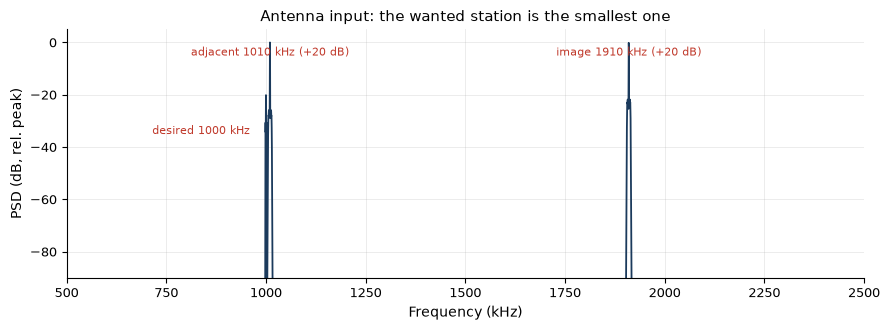

In [3]:
fs = 8_000_000
dur = 0.03
t = np.arange(int(fs * dur)) / fs
IF = 455e3
f_des, f_adj, f_img = 1000e3, 1010e3, 1000e3 + 2 * IF

def programme(n, bw=4500.0):
    """Band-limited noise standing in for speech/music (unit RMS)."""
    x = sosfiltfilt(butter(10, bw, fs=fs, output="sos"), rng.standard_normal(n))   # sharp audio filter, as at a transmitter
    return x / np.std(x)

msg_des = np.sin(2 * np.pi * 1000 * t)
stations = {"desired 1000 kHz": (f_des, 1.0, 0.6 * msg_des),
            "adjacent 1010 kHz (+20 dB)": (f_adj, 10.0, 0.3 * programme(len(t))),
            "image 1910 kHz (+20 dB)": (f_img, 10.0, 0.3 * programme(len(t)))}
carriers = {k: a * (1 + mm) * np.cos(2 * np.pi * fc_ * t + rng.uniform(0, 6.28)) for k, (fc_, a, mm) in stations.items()}
noise_rf = 0.01 * rng.standard_normal(len(t))
k_des, k_adj, k_img = list(stations)
rf_in = sum(carriers.values()) + noise_rf
rf_img_only = carriers[k_des] + carriers[k_img] + noise_rf     # for Section 3
rf_adj_only = carriers[k_des] + carriers[k_adj] + noise_rf     # for Section 4
f, ax = lk.fig("wide")
lk.psd(ax, rf_in, fs, 1 << 15, scale=1e3, unit="kHz")
ax.set_xlim(500, 2500); ax.set_ylim(-90, 5); ax.set_title("Antenna input: the wanted station is the smallest one")
for name, (fc_, a, _) in stations.items():
    ax.annotate(name, (fc_ / 1e3 + (0 if a > 1 else -40), -5 if a > 1 else -35), fontsize=8,
                ha="center" if a > 1 else "right", color=lk.RED)
lk.show(f)

## 2. The superhet chain, stage by stage

1. **RF preselector**: a tunable resonant circuit centred on the wanted station (moderate Q: cheap, tracks with the LO).
2. **Mixer + local oscillator**: multiplying by $\cos 2\pi f_{LO}t$ creates $|f \pm f_{LO}|$. With
   **high-side injection** $f_{LO} = f_{RF} + f_{IF}$ = 1455 kHz, the wanted station lands at 455 kHz.
3. **IF filter**: a fixed, sharp band-pass at 455 kHz (ceramic or mechanical filters in real radios), here an
   $N$-th order Butterworth, ±5 kHz.
4. **Detector**: an envelope detector (Lab 14) followed by an audio low-pass.

### Interactive: preselector Q and IF filter order

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

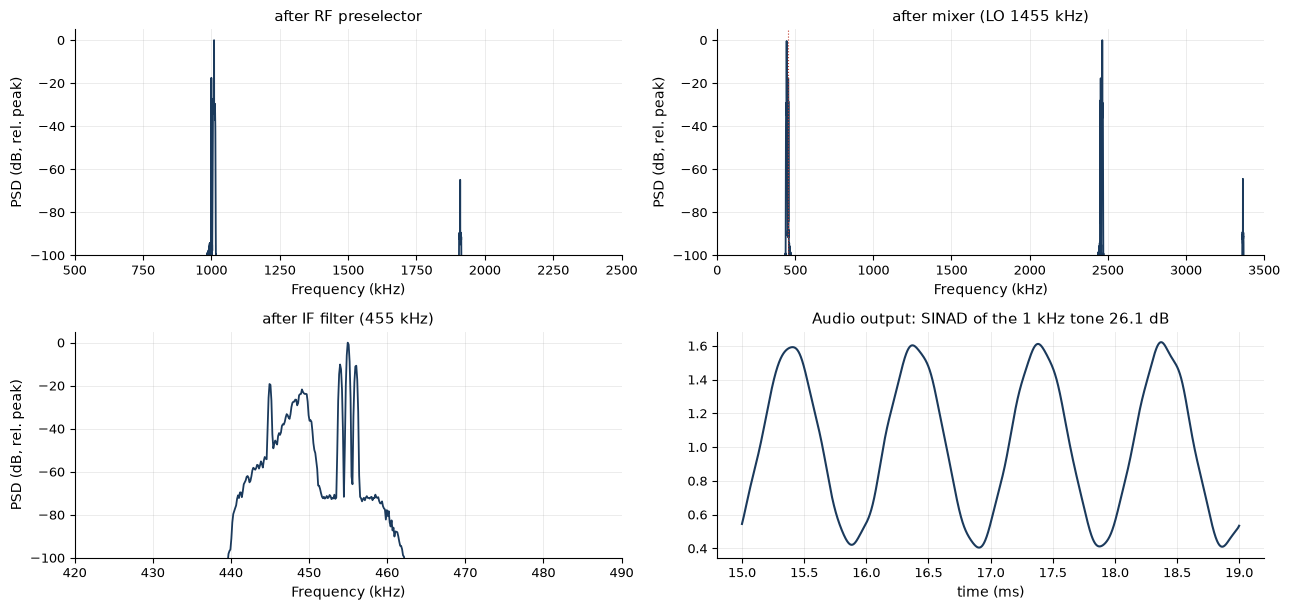

In [5]:
def preselector(f0, Q, stages=2):
    sos = np.vstack([tf2sos(*iirpeak(f0, Q, fs=fs)) for _ in range(stages)])
    return sos

def if_filter(order):
    return butter(order, [IF - 5e3, IF + 5e3], btype="band", fs=fs, output="sos")

def sinad_1khz(audio):
    """SINAD of the 1 kHz test tone: fit sin + cos at 1 kHz, everything else is noise + distortion."""
    a_ = audio[len(audio) // 4:] - np.mean(audio[len(audio) // 4:])
    tt_ = t[len(t) // 4:len(t) // 4 + len(a_)]
    B = np.stack([np.sin(2 * np.pi * 1e3 * tt_), np.cos(2 * np.pi * 1e3 * tt_)], 1)
    c, *_ = np.linalg.lstsq(B, a_, rcond=None)
    fit = B @ c
    return lk.db(np.sum(fit ** 2) / np.sum((a_ - fit) ** 2))

def superhet(x, Q=30.0, if_order=4, f_rf=f_des):
    f_lo = f_rf + IF
    a = sosfilt(preselector(f_rf, Q), x)                                  # 1. RF filter
    b = a * 2 * np.cos(2 * np.pi * f_lo * t)                              # 2. mixer
    c = sosfilt(if_filter(if_order), b)                                   # 3. IF filter
    env = np.abs(hilbert(c))                                              # 4. envelope detector
    audio = sosfiltfilt(butter(4, 4500, fs=fs, output="sos"), env)
    return a, b, c, audio

def chain_demo(Q=30.0, if_order=4):
    a, b, c, audio = superhet(rf_in, Q, if_order)
    f, axs = lk.fig((13, 6.2), 2, 2)
    for ax, sig, title, xl in [(axs[0, 0], a, "after RF preselector", (500, 2500)),
                               (axs[0, 1], b, "after mixer (LO 1455 kHz)", (0, 3500)),
                               (axs[1, 0], c, "after IF filter (455 kHz)", (420, 490))]:
        lk.psd(ax, sig, fs, 1 << 16, scale=1e3, unit="kHz"); ax.set_xlim(*xl); ax.set_ylim(-100, 5); ax.set_title(title)
    axs[0, 1].axvline(455, color=lk.RED, ls=":", lw=0.8)
    sl = slice(len(t) // 2, len(t) // 2 + int(0.004 * fs))
    axs[1, 1].plot(t[sl] * 1e3, audio[sl], color=lk.NAVY)
    axs[1, 1].set_xlabel("time (ms)"); axs[1, 1].set_title(f"Audio output: SINAD of the 1 kHz tone {sinad_1khz(audio):.1f} dB")
    lk.show(f)

lk.interact(chain_demo, Q=lk.slider(30, 3, 150, 1, "preselector Q"), if_order=lk.islider(6, 1, 10, 1, "IF filter order"))

**What you should see.** After the mixer the wanted station *and* the 1910 kHz station both sit at 455 kHz,
on top of each other: no IF filter can separate them, only the RF preselector, which has already attenuated
the image. The adjacent station at 1010 kHz becomes 465 kHz (or 445 kHz) and is removed by the IF filter if its
order is high enough. Lower the preselector Q and the image creeps up (Section 3 quantifies it); lower the
IF order to 2 or 3 and the adjacent channel ruins the audio.

## 3. The image problem and the preselector

Any mixer responds to two input frequencies that differ from $f_{LO}$ by $f_{IF}$: the wanted
$f_{LO} - f_{IF}$ and the **image** $f_{LO} + f_{IF} = f_{RF} + 2f_{IF}$. Only filtering *before* the mixer helps.
The image-rejection ratio of a preselector with two tuned stages of loaded quality factor $Q$ is about
$\big[1 + Q^2(f_{\text{img}}/f_{RF} - f_{RF}/f_{\text{img}})^2\big]$ per stage. A higher IF moves the image
further away: that is why FM broadcast receivers use 10.7 MHz and why VHF/UHF receivers use double conversion.

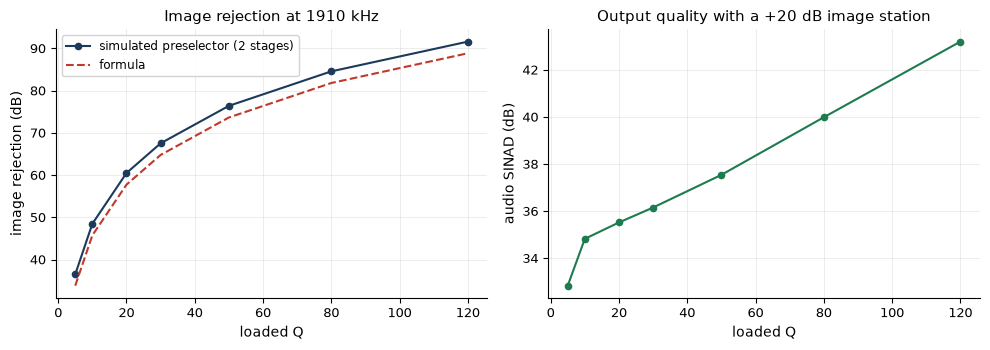

In [8]:
Qs = np.array([5, 10, 20, 30, 50, 80, 120])
irr, sinad = [], []
for Q in Qs:
    _, h_des = sosfreqz(preselector(f_des, Q), worN=[f_des], fs=fs)
    _, h_img = sosfreqz(preselector(f_des, Q), worN=[f_img], fs=fs)
    irr.append(lk.db(np.abs(h_des[0] / h_img[0]) ** 2))
    sinad.append(sinad_1khz(superhet(rf_img_only, Q, 6)[3]))
x_ = f_img / f_des - f_des / f_img
f, ax = lk.fig("row2", 1, 2)
ax[0].plot(Qs, irr, "o-", label="simulated preselector (2 stages)")
ax[0].plot(Qs, 2 * lk.db(1 + (Qs * x_) ** 2), "--", color=lk.RED, label="formula")
ax[0].set_xlabel("loaded Q"); ax[0].set_ylabel("image rejection (dB)"); ax[0].legend(); ax[0].set_title("Image rejection at 1910 kHz")
ax[1].plot(Qs, sinad, "o-", color=lk.GREEN); ax[1].set_xlabel("loaded Q"); ax[1].set_ylabel("audio SINAD (dB)")
ax[1].set_title("Output quality with a +20 dB image station")
lk.show(f)

**What you should see.** Image rejection rises by about 40 dB per decade of Q (two stages) and matches the
formula. With only the desired and the +20 dB image station on the air, SINAD climbs with Q until the image
is buried; with a low-Q preselector the image is a co-channel interferer that no later stage can remove.

### Try it yourself 3.1
A superhet with high-side LO and a 10.7 MHz IF is tuned to 98.1 MHz. What is the image frequency (MHz)?

In [10]:
answer_3_1 = None
lk.check("3.1 image of 98.1 MHz with a 10.7 MHz IF", answer_3_1, 98.1 + 2 * 10.7, atol=0.01)

[TODO] 3.1 image of 98.1 MHz with a 10.7 MHz IF: not attempted yet: replace the None with your answer

## 4. IF selectivity and adjacent channels

The IF filter sets **selectivity**: how strongly a station one channel away (10 kHz on medium wave in
Europe/ITU Region 1 uses 9 kHz) is rejected. Higher-order filters have steeper skirts; real radios use
ceramic, crystal or mechanical filters with shape factors (60 dB / 6 dB bandwidth ratio) of 2 or better.

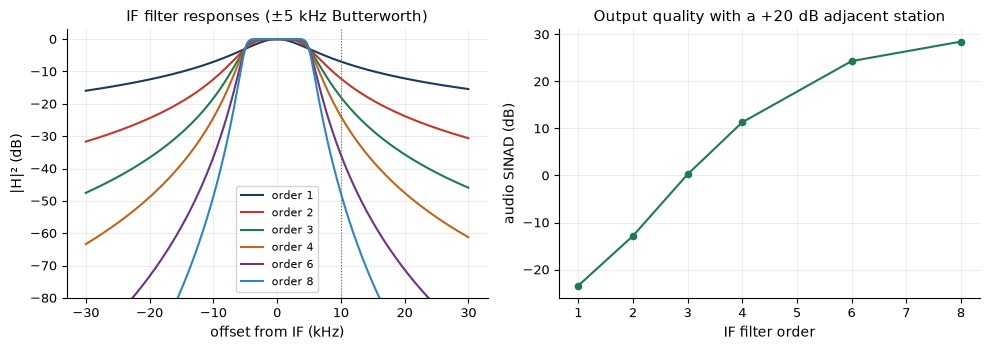

IF order,rejection at +10 kHz (dB),SINAD (dB)
1,6.9,-23.4
2,12.2,-12.9
3,17.9,0.2
4,23.8,11.3
6,35.7,24.3
8,47.6,28.5


In [12]:
orders = [1, 2, 3, 4, 6, 8]
f, ax = lk.fig("row2", 1, 2)
fr = np.linspace(IF - 30e3, IF + 30e3, 2000)
acs = []
for o in orders:
    _, H = sosfreqz(if_filter(o), worN=fr, fs=fs)
    ax[0].plot((fr - IF) / 1e3, lk.db(np.abs(H) ** 2), label=f"order {o}")
    _, h10 = sosfreqz(if_filter(o), worN=[IF + 10e3], fs=fs)
    acs.append([o, -lk.db(np.abs(h10[0]) ** 2), sinad_1khz(superhet(rf_adj_only, 10, o)[3])])
ax[0].axvline(10, color=lk.RED, ls=":", lw=0.8); ax[0].set_ylim(-80, 3); ax[0].set_xlabel("offset from IF (kHz)")
ax[0].set_ylabel("|H|² (dB)"); ax[0].legend(fontsize=8); ax[0].set_title("IF filter responses (±5 kHz Butterworth)")
ax[1].plot(orders, [a_[2] for a_ in acs], "o-", color=lk.GREEN); ax[1].set_xlabel("IF filter order")
ax[1].set_ylabel("audio SINAD (dB)"); ax[1].set_title("Output quality with a +20 dB adjacent station")
lk.show(f)
lk.table(acs, ["IF order", "rejection at +10 kHz (dB)", "SINAD (dB)"], fmt={1: ".1f", 2: ".1f"})

**What you should see.** Each extra order adds roughly 6 dB/octave of skirt. With a +20 dB neighbour, SINAD is
hopeless for orders 1–3 (the neighbour's carrier beats with ours in the envelope detector) and becomes good
only by order 6–8, once the neighbour is pushed 35–50 dB down. That is why AM radios use ceramic or mechanical
filters with steep skirts.

## 5. Automatic gain control

Received signals vary over 100 dB (distance, fading, a passing truck). The **AGC** measures the IF signal level
and adjusts the gain to keep the detector input constant. Its time constants are a compromise: fast **attack**
so a strong signal does not overload the detector, slow **decay** so the AGC does not follow (and flatten) the
AM modulation itself. We feed the IF stage a station whose level steps from 0 dB to −30 dB and back up to −10 dB.

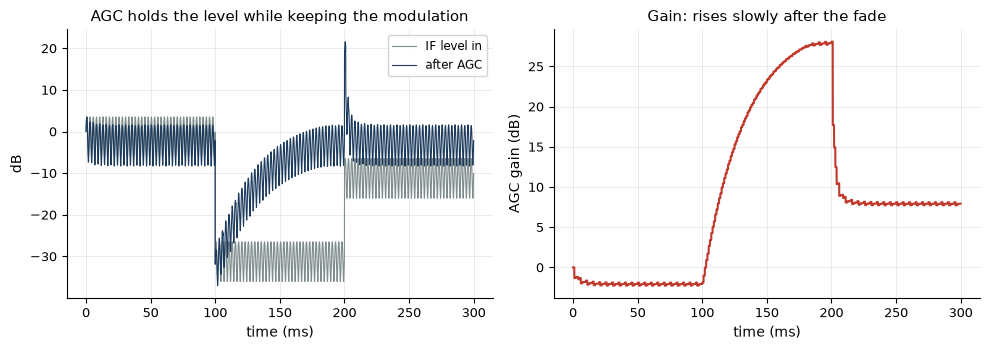

In [15]:
fs_agc = 100_000
ta = np.arange(int(0.3 * fs_agc)) / fs_agc
level = np.where(ta < 0.1, 1.0, np.where(ta < 0.2, 10 ** (-30 / 20), 10 ** (-10 / 20)))
env_in = level * (1 + 0.5 * np.sin(2 * np.pi * 400 * ta))           # AM envelope at the IF
def agc(x, ref=1.0, block=100, attack=0.5, decay=0.03):
    """Block-wise AGC in the log domain: each 1 ms block, measure the mean output level and
    correct the gain by a fraction of the error (large fraction = fast attack when too loud,
    small fraction = slow decay/recovery when too quiet)."""
    g = 1.0
    out = np.empty_like(x); gains = np.empty_like(x)
    for i in range(0, len(x), block):
        y = g * x[i:i + block]
        out[i:i + block], gains[i:i + block] = y, g
        err_db = 20 * np.log10(ref / max(np.mean(np.abs(y)), 1e-12))
        g *= 10 ** ((attack if err_db < 0 else decay) * err_db / 20)
    return out, gains
out, gains = agc(env_in)
f, ax = lk.fig("row2", 1, 2)
ax[0].plot(ta * 1e3, lk.db(env_in ** 2), color=lk.GRAY, lw=0.8, label="IF level in")
ax[0].plot(ta * 1e3, lk.db(out ** 2), color=lk.NAVY, lw=0.8, label="after AGC")
ax[0].set_xlabel("time (ms)"); ax[0].set_ylabel("dB"); ax[0].legend(); ax[0].set_title("AGC holds the level while keeping the modulation")
ax[1].plot(ta * 1e3, lk.db(gains ** 2), color=lk.RED); ax[1].set_xlabel("time (ms)"); ax[1].set_ylabel("AGC gain (dB)")
ax[1].set_title("Gain: rises slowly after the fade")
lk.show(f)

**What you should see.** After each step the output returns to the same average level within a few tens of
milliseconds, while the 400 Hz modulation passes through: the loop is slow compared with the audio. Make
the decay much faster and the AGC starts to strip the modulation (an experiment worth trying).

## 6. Zero-IF and low-IF: IQ imbalance instead of images

Integrated transceivers avoid the external high-Q image and IF filters altogether:

* **Zero-IF** (direct conversion, the AD9364 in the B200): a quadrature mixer at $f_{LO} = f_{RF}$ brings the
  channel straight to 0 Hz. The "image" is the channel's own mirror, so IQ imbalance only adds a little
  self-interference; the costs are **DC offset**, LO leakage and flicker noise right in the band.
* **Low-IF** (many Bluetooth/GNSS chips): the channel lands at a small IF (here +100 kHz) away from DC, but its
  image is at −100 kHz, often an *adjacent channel* that may be 30 dB stronger. With a perfect quadrature
  mixer the image is rejected completely; with gain error $g$ and phase error $\phi$, only by the IRR (Lab 1).

### Interactive: the low-IF image problem

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

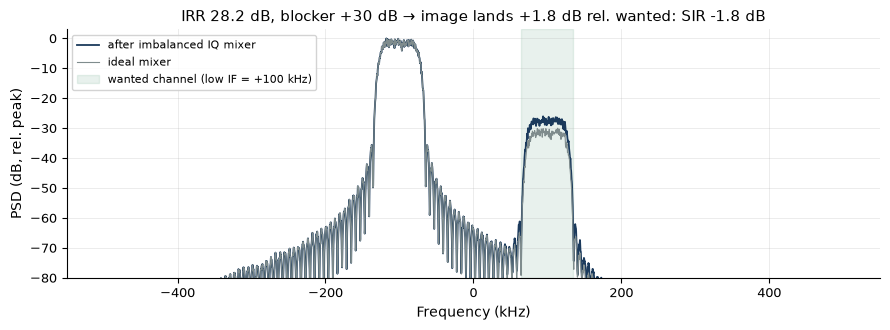

In [18]:
fsb = 1_000_000
nb = 1 << 16
tb = np.arange(nb) / fsb
qpsk = cl.get_constellation("qpsk")

def qpsk_channel(f0, power_db, rs=50e3, sps=20):
    s_ = cl.shape(qpsk.modulate(cl.random_bits(2 * (nb // sps + 20), rng)), cl.rrc_taps(0.35, sps, 8), sps)[:nb]
    return 10 ** (power_db / 20) * s_ * np.sqrt(sps) * np.exp(2j * np.pi * f0 * tb)

def low_if_demo(gain_db=0.5, phase_deg=3.0, blocker_db=30.0):
    wanted = qpsk_channel(100e3, 0.0)
    blocker = qpsk_channel(-100e3, blocker_db)
    y = cl.iq_imbalance(wanted + blocker, gain_db, phase_deg)
    g, ph = 10 ** (gain_db / 20), np.deg2rad(phase_deg)
    irr = lk.db(np.abs((1 + g * np.exp(1j * ph)) / 2) ** 2 / max(np.abs((1 - g * np.exp(-1j * ph)) / 2) ** 2, 1e-15))
    sir = irr - blocker_db              # wanted at 0 dB; the blocker's image arrives IRR dB below the blocker
    f, ax = lk.fig("wide")
    lk.psd(ax, y, fsb, 4096, scale=1e3, unit="kHz", label="after imbalanced IQ mixer")
    lk.psd(ax, wanted + blocker, fsb, 4096, scale=1e3, unit="kHz", color=lk.GRAY, lw=0.8, label="ideal mixer")
    ax.axvspan(65, 135, color=lk.GREEN, alpha=0.1, label="wanted channel (low IF = +100 kHz)")
    ax.set_ylim(-80, 3); ax.legend(loc="upper left", fontsize=8)
    ax.set_title(f"IRR {irr:.1f} dB, blocker +{blocker_db:.0f} dB → image lands {blocker_db - irr:+.1f} dB rel. wanted: SIR {sir:.1f} dB")
    lk.show(f)

lk.interact(low_if_demo, gain_db=lk.slider(0.5, 0, 2, 0.05, "gain error (dB)"),
            phase_deg=lk.slider(3, 0, 10, 0.25, "phase error (deg)"),
            blocker_db=lk.slider(30, 0, 50, 1, "blocker at −IF (dB)"))

**What you should see.** With a perfect mixer (grey) the band around +100 kHz contains only the wanted
signal. With 0.5 dB / 3° of imbalance the IRR is about 30 dB, so a +30 dB blocker's image lands right on top
of the wanted signal at roughly 0 dB SIR: QPSK is lost. Low-IF receivers therefore need IRRs of 40–60 dB, which
means calibration (Lab 1's blind estimator) or very careful layout.

### Try it yourself 6.1
A low-IF receiver must tolerate a +35 dB adjacent-channel blocker and still have 15 dB SIR. What IRR (dB) does it need?

In [20]:
answer_6_1 = None
lk.check("6.1 required IRR (dB)", answer_6_1, 35 + 15, atol=0.1)

[TODO] 6.1 required IRR (dB): not attempted yet: replace the None with your answer

## Key takeaways
* The superhet converts every station to one fixed IF where a sharp filter does the selection.
* The image ($f_{RF} + 2f_{IF}$ for high-side LO) must be rejected *before* the mixer; higher IF or
  double conversion makes that easier.
* IF filter order sets adjacent-channel selectivity; AGC uses fast attack and slow decay.
* Zero-IF removes images and IF filters but brings DC offset and flicker noise; low-IF moves away from DC but
  turns IQ imbalance into adjacent-channel image interference.

## Going further (hardware: USRP B200 / GNU Radio)
* The B200 is zero-IF. Tune it exactly onto a strong carrier and then 200 kHz away; compare the DC spur and the
  mirror image of the carrier (gr01). Disable UHD's automatic IQ balance (`set_auto_iq_balance(False)`) and
  measure the IRR as in Lab 1.
* Emulate a superhet in software: capture at 2 MS/s around a medium-wave or aviation band, then apply Section 2's
  chain digitally with an NCO as the LO (this is the "digital IF" of every modern radio).

## Exercises
1. **(Warm-up)** For low-side injection ($f_{LO} = f_{RF} - f_{IF}$), where is the image? Which choice makes the
   LO tuning range ratio smaller for the 530–1700 kHz band?
2. **(Core)** Add a double-conversion stage (first IF 10.7 MHz, second IF 455 kHz) and compute the image
   rejection of each conversion with the same preselector.
3. **(Core)** Add a third-order nonlinearity ($y = x + a_3x^3$) before the mixer and find the two-tone
   third-order intercept point (IIP3) by simulation.
4. **(Stretch)** Implement a Weaver or Hartley image-reject mixer and plot its image rejection versus
   phase error of the 90° network.

In [22]:
lk.summary()

[good] Lab 15 finished in 2.2 s. Self-checks: 0 passed, 0 failed, 2 still to do.